# Классификация текстов с использованием Наивного Байесовского Классификатора

## Задание 1 (1 балл)

Откройте данные. Узнайте, сколько в них спам- и не спам-писем. Визуализируйте полученные соотношение подходящим образом.

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import model_selection
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from hyperopt import hp, fmin, tpe, Trials 
import warnings
warnings.filterwarnings('ignore')

# Прочитаем файл с исходными данными:
data = pd.read_csv('spam_or_not_spam.csv')

# Выведем результат на экран:
data.head()

,email,label
0,date wed NUMBER aug NUMBER NUMBER NUMBER NUMB...,0
1,martin a posted tassos papadopoulos the greek ...,0
2,man threatens explosion in moscow thursday aug...,0
3,klez the virus that won t die already the most...,0
4,in adding cream to spaghetti carbonara which ...,0


In [44]:
# Рассчитаем частоты для классов:
data.groupby('label').count()

,email
label,
0,2500
1,499


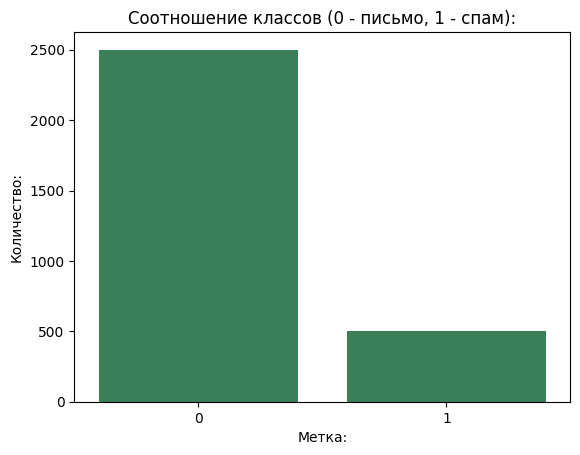

In [45]:
# Визуализируем результат:

sns.countplot(data = data,
              x =  'label',
              orient = 'h',
              color = 'seagreen',
              stat = 'count',
              legend = 'auto')

# Настройка заголовков осей координат:
plt.xlabel('Метка:')
plt.ylabel('Количество:')
# Настройка заголовка и отображение графика:
plt.title('Соотношение классов (0 - письмо, 1 - спам):')
plt.show()

## Задание 2 (2 балла)

Вам необходимо предобработать ваши данные и перевести их в векторный вид. Подгрузим необходимый модуль:

In [46]:
from sklearn.feature_extraction.text import CountVectorizer

Замените в данных все пустые строки и строки, состоящие из пробелов, на пропуски (NaN). После этого удалите из данных все строки, в которых наблюдаются пропущенные значения.

In [47]:
data = data.dropna(axis=0)

Переводим данные в векторный вид:

In [48]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(data["email"])

Определите, сколько теперь признаков в нашем наборе данных:

In [49]:
X.shape

(2999, 34116)

## Задание 3 (2 балла)

Определите целевую переменную и признаки:

In [50]:
X = X
y = data['label']

Разделите выборку на обучающую и тестовую, используя стратифицированное разбиение (параметр `stratify` установите в значение вектора ответов y) размер тестовой выборки (`test_size`) возьмите как 0.25, параметр `random_state` определите со значением 42:

In [51]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, 
    stratify = y, 
    random_state =  42,
    test_size = 0.25
)
print('Train shape: {}'.format(X_train.shape))
print('Test shape: {}'.format(X_test.shape))

Train shape: (2249, 34116)
Test shape: (750, 34116)


Рассчитайте среднее значение целевой переменной по тестовой выборке:

In [52]:
y_test.mean()

0.16666666666666666

## Задание 4 (3 балла)

Определите и обучите подходящий алгоритм с параметром alpha = 0.01

In [53]:
bayes = ComplementNB(alpha=0.01)
bayes.fit(X_train, y_train)
predicted = bayes.predict(X_test)
correct = (predicted == y_test).sum() / y_test.shape[0] * 100
print('Правильных предсказаний на тестовой выборке: {}%'.format(correct))

Правильных предсказаний на тестовой выборке: 98.93333333333332%


Оцените результат с точки зрения всех известных вам метрик (не менее трёх):

In [54]:
print('Precision = {} (on test sample)'.format(round(precision_score(y_test, predicted), 3)))
print('Accuracy = {} (on test sample)'.format(round(accuracy_score(y_test, predicted), 3)))
print('Recall = {} (on test sample)'.format(round(recall_score(y_test, predicted), 3)))

Precision = 0.992 (on test sample)
Accuracy = 0.989 (on test sample)
Recall = 0.944 (on test sample)


Нарисуйте ROC-кривую:

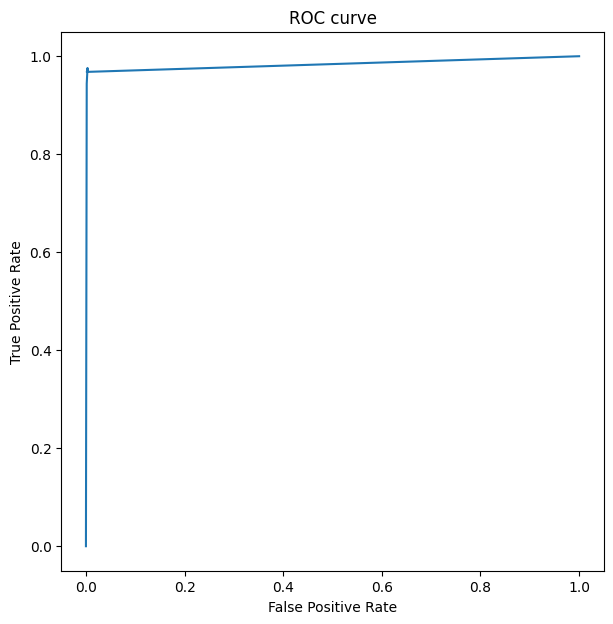

In [55]:
alphas = [0.01, 0.12, 0.23, 0.33, 0.5, 0.7, 0.8, 0.9]
false_positive_rates = [0.0]
true_positive_rates = [0.0]
for alpha in alphas:
    bayes = ComplementNB(alpha=alpha)
    bayes.fit(X_train, y_train)
    predicted = bayes.predict(X_test)    
    false_positive_rate, true_positive_rate, _ = roc_curve(y_test, predicted)
    false_positive_rates.append(false_positive_rate[1])
    true_positive_rates.append(true_positive_rate[1])   
false_positive_rates.append(1.0)
true_positive_rates.append(1.0)
# Создаем график:
plt.figure(figsize=(7, 7))
# Рисуем кривую:
plt.plot(false_positive_rates, true_positive_rates, label='Сглаженные значения ROC-AUC')
plt.title('ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

## Задание 5 (3 балла)

Переберите несколько значений alpha с помощью кросс-валидации. Оцените, зависит ли от этого параметра качество классификации.

In [56]:
alpha = [0.01, 0.05, 0.1, 0.5]

for a in alpha:
    NB = ComplementNB(alpha=a)
    NB.fit(X_train, y_train)
    kf = model_selection.KFold(n_splits=5)
    cv_metrics = model_selection.cross_validate(
        # Модель:
        estimator=NB,
        # Матрица наблюдений X:
        X=X,
        # Вектор ответов y:
        y=y,
        # Кросс-валидатор:
        cv=kf,
        # Метрика:
        scoring='accuracy',
        # Подсчёт метрики на тренировочных фолдах:
        return_train_score=True
    )
    print('Alpha = {}'.format(a))
    print('Train k-fold mean accuracy: {:.2f}'.format(np.mean(cv_metrics['train_score'])))
    print('Test k-fold mean accuracy: {:.2f}'.format(np.mean(cv_metrics['test_score'])))
    print('\n')

Alpha = 0.01
Train k-fold mean accuracy: 1.00
Test k-fold mean accuracy: 0.82


Alpha = 0.05
Train k-fold mean accuracy: 1.00
Test k-fold mean accuracy: 0.82


Alpha = 0.1
Train k-fold mean accuracy: 1.00
Test k-fold mean accuracy: 0.82


Alpha = 0.5
Train k-fold mean accuracy: 1.00
Test k-fold mean accuracy: 0.82


